# Lorenz63: Chaotic ODE

**rodeo** is also capable of solving multivariate ODEs. We will demonstrate with a multivariate ODE system called **Lorenz63**. This system has a chaotic regime depending on the initial values. For initial values $\vv = (-12, -5, 28)$, there is a deterministic phase which we can use to compare to the solution given by the `odeint` from `scipy`. The Lorenz equation is defined as follows:

\begin{equation*}
  \begin{aligned}
    \frac{dx}{dt} &= \sigma(y - x), \\
    \frac{dy}{dt} &= x(\rho - z) - y, \\
    \frac{dz}{dt} &= xy - \beta z, \\
    \xx_0 &= (-12,-5,28).
  \end{aligned}
\end{equation*}
where $(\rho, \sigma, \beta) = (28, 10, 8/3)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy.integrate import odeint

from rodeo.ibm import ibm_init
from rodeo.ode import *
from jax.config import config
config.update("jax_enable_x64", True)

We explore a different interrogation method in this example. Our default is `interrogate_rodeo` which takes the current predictive mean as the interrogation. `interrogate_chkrebtii` instead takes a random draw centered at the predictive mean. [Chkrebtii et al (2016)] explains that this allows for the solver to capture the uncertainty better.

In [13]:
# ODE function
def ode_fun_jax(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t[:,0]
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return jnp.array([[dx], [dy], [dz]])


# problem setup and intialization
n_deriv = 1  # Total state; q
n_obs = 3  # Total observations
n_deriv_prior = 3 # p

# Time interval on which a solution is sought.
n_steps = 50000
tmin = 0.
tmax = 20.
theta = jnp.array([28, 10, 8/3])

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = .5
sigma = jnp.array([sigma]*n_obs)

# Initial W for jax block
W_mat = np.zeros((n_obs, 1, n_deriv_prior))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)

# Initial x0 for jax block
x0_block = jnp.array([[-12., 70., 550.], [-5., 125, -1321.], [38., -124/3, -15658/9]])

# Get parameters needed to run the solver
dt = (tmax-tmin)/n_steps  # step size
n_order = jnp.array([n_deriv_prior]*n_obs)
ode_init = ibm_init(dt, n_order, sigma)

# Jit solver
draws = 10
sim_jit = jax.jit(solve_sim, static_argnums=(1, 7, 11))
results = np.zeros((draws, n_steps+1, n_obs))
for i in range(draws):
    key = jax.random.PRNGKey(i)
    xt = sim_jit(key=key, fun=ode_fun_jax,
            x0=x0_block, theta=theta,
            tmin=tmin, tmax=tmax, n_steps=n_steps,
            W=W_block, **ode_init, interrogate=interrogate_chkrebtii)
    results[i] = xt[:, :, 0]
    

In [8]:
import warnings
warnings.filterwarnings('ignore')
from diffrax import SaveAt
from diffrax import diffeqsolve, Dopri8, ODETerm, PIDController


In [9]:
def rax_fun(t, X_t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return jnp.array([dx, dy, dz])
term = ODETerm(rax_fun)
solver = Dopri8()
stepsize = PIDController(rtol=1e-20, atol=1e-8)

In the plot below, we see that due to the chaotic nature of the ODE, the probabilistic solver produces different paths due to uncertainty.

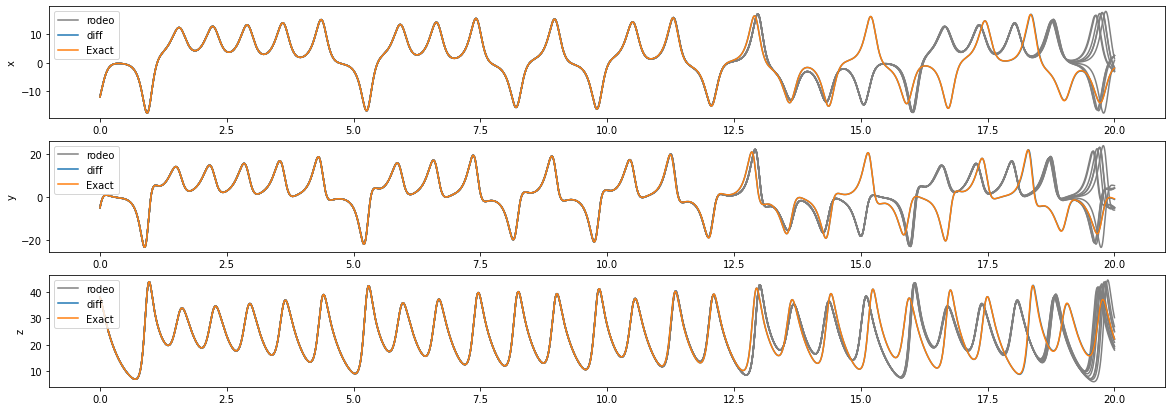

In [14]:
def ode_fun(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return np.array([dx, dy, dz])

# Initial x0 for odeint
ode0 = np.array([-12, -5, 38])

# Get exact solutions for the Lorenz System
tseq = np.linspace(tmin, tmax, n_steps+1)
saveat = SaveAt(ts=tseq)
exact = odeint(ode_fun, ode0, tseq, args=(theta,), rtol=1e-20)
X_t = diffeqsolve(term, solver, args = theta, t0=tmin, t1=tmax, dt0 = dt,
                  y0=jnp.array(ode0), saveat=saveat, stepsize_controller=stepsize).ys

# Graph the results
_, axs = plt.subplots(3, 1, figsize=(20, 7))
ylabel = ['x', 'y', 'z']
for i in range(3):
    for j in range(draws):
        if j==0:
            axs[i].plot(tseq, results[j, :, i], color="gray", alpha=1, label="rodeo")
        else:
            axs[i].plot(tseq, results[j, :, i], color="gray", alpha=1)
    axs[i].set_ylabel(ylabel[i])
    axs[i].plot(tseq, X_t[:, i], label='diff')
    axs[i].plot(tseq, exact[:, i], label='Exact')
    axs[i].legend(loc='upper left')